In [35]:
"""
CSC 461 - Final Project
Thomas Torres
Eigen Faces Application of LocalMAP - Apply LocalMAP to a new dataset
"""
import numpy as np
from sklearn import datasets
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from skimage.io import imshow # for rendering face images
from sklearn.metrics import silhouette_score
from scipy.stats import norm
import time

#large vis installization
!git clone https://github.com/lferry007/LargeVis
!g++ LargeVis.cpp main.cpp -o LargeVis -lm -pthread -lgsl -lgslcblas -Ofast -march=native -ffast-math
!sudo python setup.py install
import LargeVis

!git clone https://github.com/ThomasTorres2024/CSC_461_Project
#i cloned my repo to make some of the testing and eval nicer

#install all relevant libraries
libraries=['phate','opentsne',
'umap-learn',
'hnne',
'contrastive-ne',
'trimap',
'tqdm',
'pacmap']
for lib in libraries:
  !pip install {lib}

#models
from pacmap import LocalMAP




#loads and install the dataset if it is not installed
all_face_info=datasets.fetch_olivetti_faces(data_home=None, shuffle=False, random_state=0, download_if_missing=True)

#get images and labels
image_set = all_face_info['images']
label_set = all_face_info['target']


fatal: destination path 'LargeVis' already exists and is not an empty directory.
cc1plus: fatal error: LargeVis.cpp: No such file or directory
compilation terminated.
cc1plus: fatal error: main.cpp: No such file or directory
compilation terminated.
python3: can't open file '/content/setup.py': [Errno 2] No such file or directory
fatal: destination path 'CSC_461_Project' already exists and is not an empty directory.


(400, 64, 64)
(64, 64)


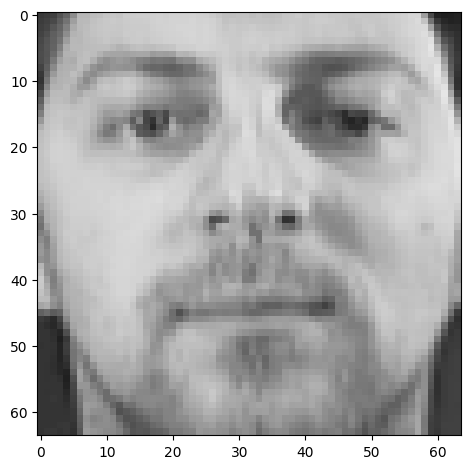

In [2]:
#visualize the faces in the dataset
print(image_set.shape)
#img size is 64x64, there are 400 of them
print(image_set[67].shape)
imshow(image_set[67])



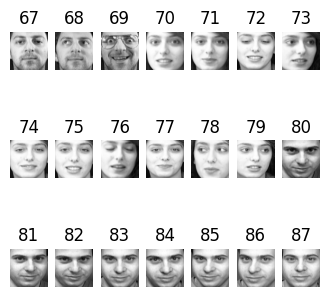

In [3]:
"""Produces a visualization of faces from the dataset"""
def render_faces(imgs, len : int, width : int) -> None:

    #create figure
    fig, axes = plt.subplots(len, width, figsize=(4, 4))

    img_idx:int=67

    #assign image at each step, give the id of the image
    for i in range(len):
        for j in range(width):
            loaded_img = imgs[img_idx]
            img_idx+=1

            # Display the image on the axes
            axes[i][j].imshow(loaded_img, cmap='gray') # 'cmap' specifies the colormap, 'gray' is common for grayscale images
            axes[i][j].set_title(f'{img_idx-1}')
            axes[i][j].axis('off')

    #render the figure
    plt.show()

render_faces(image_set,3,7)

In [4]:
"""Condenses image into a 64^2 list"""
def package_array(image) -> list[int]:
  img_arr = []
  for i in range(64):
      for j in range(64):
        img_arr.append(image[i][j])
  return img_arr

"""Package each image into its respective dataset, and then export it as an numpy array"""
def package_dataset(image_set) -> list[list[int]]:
  packaged_dataset = []
  for image in image_set:
    packaged_dataset.append(package_array(image))
  #return packaged dataset
  return np.array(packaged_dataset)

"""Returns dataset of the images and what person they correspond to"""
def get_labels(label_set) -> list[int]:
  vals=[]
  for val in label_set:
    vals.append(val)
  return np.array(vals)

#get image set and labels
np_arr_img_set=package_dataset(image_set)
np_arr_labels = get_labels(label_set)
np.save('eigen_faces_dataset.npy', np_arr_img_set)
np.save('eigen_faces_labels.npy', np_arr_labels)

Computing approximate kNN graph with annoy


Finished epoch 0/200, loss 1964.216
Finished epoch 40/200, loss 11150.680
Finished epoch 80/200, loss 4340.530
Finished epoch 120/200, loss 4041.328
Finished epoch 160/200, loss 4075.429


Computing approximate kNN graph with annoy


Finished epoch 0/200, loss 36473.404
Finished epoch 40/200, loss 24747.248
Finished epoch 80/200, loss 22313.619
Finished epoch 120/200, loss 19937.395
Finished epoch 160/200, loss 17576.933


Computing approximate kNN graph with annoy


Finished epoch 0/200, loss 23708.531
Finished epoch 40/200, loss 20663.837
Finished epoch 80/200, loss 20431.453
Finished epoch 120/200, loss 20253.522
Finished epoch 160/200, loss 20093.617


Calculating PHATE...
  Running PHATE on 400 observations and 4096 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.46 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.01 seconds.
    Calculating affinities...
    Calculated affinities in 0.04 seconds.
  Calculated graph and diffusion operator in 0.54 seconds.
  Calculating optimal t...
    Automatically selected t = 26
  Calculated optimal t in 0.09 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.08 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.20 seconds.
Calculated PHATE in 1.94 seconds.


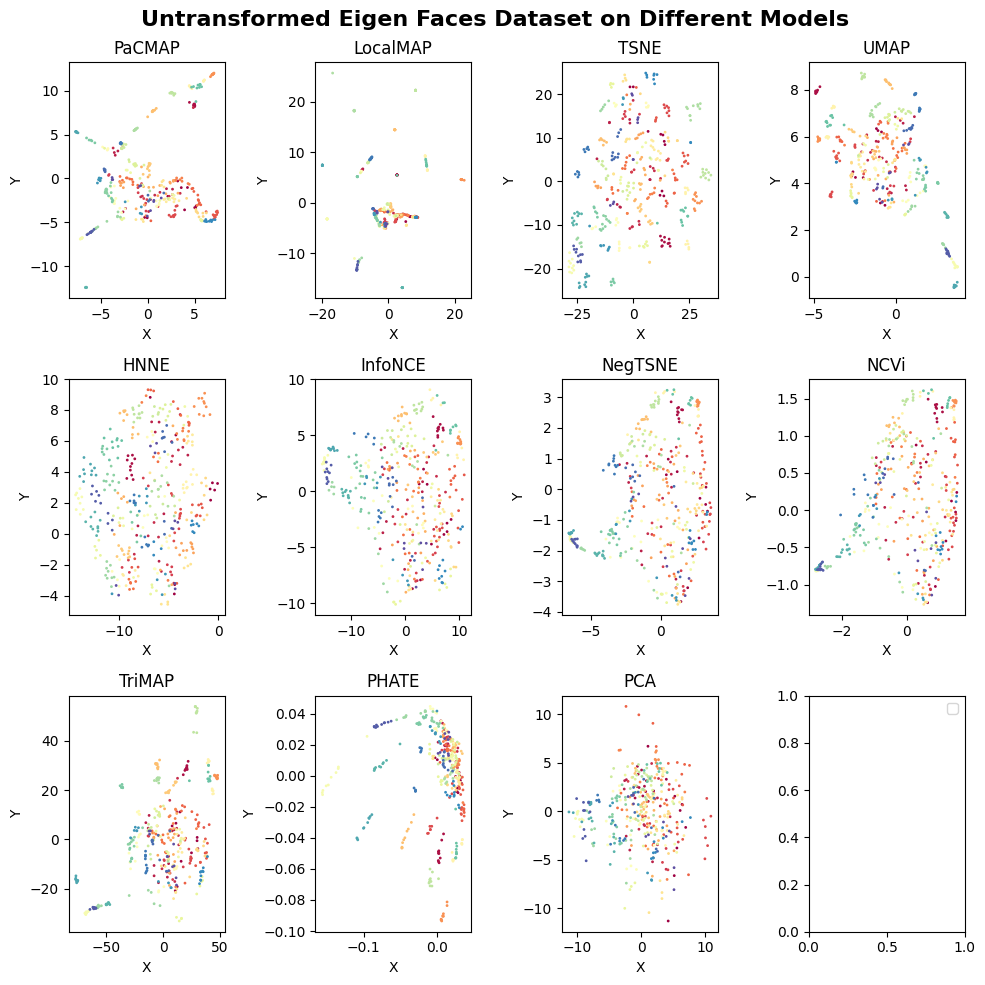

In [59]:
from pacmap import LocalMAP
import numpy as np
import matplotlib.pyplot as plt


X = np.load("./eigen_faces_dataset.npy", allow_pickle=True)
y = np.load("./eigen_faces_labels.npy",allow_pickle=True)

"""Function that is slightly modified code from the LocalMAP repository for evaluating
different models on data.
@param model_name - name of the model we want to evaluate data on
@param data_set_name - what to save the embedded data as
@i - index of the saved data
@X - the data we want to embed
@return Returns the transformed data
"""
def evaluate_model(model_name : str, data_set_name : str, i : int, X,y):
    if model_name == 'PaCMAP':
        import pacmap
        model = pacmap.PaCMAP()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "LocalMAP":
        model = LocalMAP()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "TSNE":
        # import openTSNE
        # model = openTSNE.TSNE(n_jobs=-1)
        from sklearn.manifold import TSNE
        model = TSNE()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "UMAP":
        import umap
        model = umap.UMAP()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "HNNE":
        import hnne
        model = hnne.HNNE()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "InfoNCE":
        import cne
        model = cne.CNE()
        start_time = time.time()
        X_trans = model.fit_transform(X.astype(float))
        total_time = time.time()-start_time
    elif model_name == "NegTSNE":
        import cne
        model = cne.CNE(loss_mode="neg")
        start_time = time.time()
        X_trans = model.fit_transform(X.astype(float))
        total_time = time.time()-start_time
    elif model_name == "NCVi":
        import cne
        model = cne.CNE(loss_mode="nce",optimizer="adam")
        start_time = time.time()
        X_trans = model.fit_transform(X.astype(float))
        total_time = time.time()-start_time
    elif model_name == "TriMAP":
        import trimap
        model = trimap.TRIMAP()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "PHATE":
        import phate
        model = phate.PHATE(n_jobs=-1)
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "PCA":
        from sklearn.decomposition import PCA
        model = PCA(n_components=2)
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time

    # save the embedding into the embedding folder
    np.save(f'{data_set_name}_{model_name}_embedding_{i}.npy',X_trans)
    return X_trans


model_names=[]

"""Evaluation Function for Eigen-Faces"""
def eval_data(data_name : str):

    models=["PaCMAP","LocalMAP","TSNE","UMAP","HNNE","InfoNCE","NegTSNE","NCVi","TriMAP","PHATE","PCA"]
    fig, axes = plt.subplots(3, 4, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(len(models)):
      model_name = models[i]
      #10 diff trials with each model
      X_trans=evaluate_model(model_name, data_name, i,X,y)
      ax = axes[i]
      ax.scatter(X_trans[:, 0], X_trans[:, 1], cmap="Spectral", c=y, s=1)
      ax.set_title(f"{model_name}")
      ax.set_xlabel("X")
      ax.set_ylabel("Y")

      #save embedding
      np.save(f'{data_name}_{model_name}_embedding.npy',X_trans)

    fig.suptitle('Untransformed Eigen Faces Dataset on Different Models', fontsize=16, fontweight='bold')
    #show layout
    plt.tight_layout()
    plt.legend()
    plt.show()

eval_data("Eigen Faces")




In [ ]:

y=np.load("./eigen_faces_labels.npy",allow_pickle=True)
silhou_score=[]
ITERATIONS : int = 9
for i in range(ITERATIONS):
    file_name : str = f"eigen_faces_localmap_embedding{i}.npy"

    # load the dataset
    embedding = np.load(file_name)
    # calculate the silhouette score
    silhou_score.append(silhouette_score(embedding, y))

mean_score = np.mean(silhou_score)
std_score = np.std(silhou_score, ddof=1) # ddof=1 for sample standard deviation
n = len(silhou_score)

# Calculate standard error of the mean
sem = std_score / np.sqrt(n)
confidence_level = 0.95
lower_bound, upper_bound = norm.interval(confidence_level, loc=mean_score, scale=sem)
print(lower_bound, upper_bound)
print(mean_score)




0.10505128754626789 0.12762839244354687
0.11633984


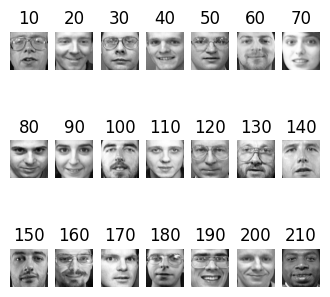

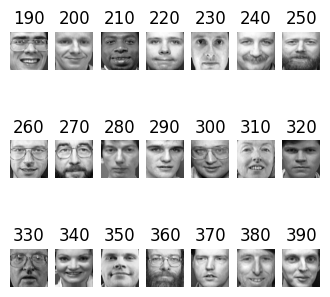

In [ ]:
"""Produces a visualization of faces from the dataset"""
def render_faces(imgs, len : int, width : int,k) -> None:

    #create figure
    fig, axes = plt.subplots(len, width, figsize=(4, 4))

    img_idx:int=67

    #assign image at each step, give the id of the image
    for i in range(len):
        for j in range(width):
            loaded_img = imgs[k]
            img_idx+=1

            # Display the image on the axes
            axes[i][j].imshow(loaded_img, cmap='gray') # 'cmap' specifies the colormap, 'gray' is common for grayscale images

            # Optional: Add a title to the plot
            axes[i][j].set_title(f'{k}')

            # Optional: Remove axis ticks for cleaner image display
            axes[i][j].axis('off')
            k+=10

    #render the figure
    plt.show()

render_faces(image_set,3,7,10)
render_faces(image_set,3,7,190)

In [38]:
from pacmap import LocalMAP
import numpy as np
import matplotlib.pyplot as plt


#load datasets we just created
X = np.load("./eigen_faces_dataset.npy", allow_pickle=True)
y = np.load("./eigen_faces_labels.npy",allow_pickle=True)

#transform data
mean_vec = np.mean(X, axis=0)
X = np_arr_img_set.reshape(X.shape[0], -1)
C = X - mean_vec
D=C @ np.transpose(C)

#now we have cov matrix, we need to get the top k eig-vectors
eigenvalues, eigenvectors = np.linalg.eig(D@np.transpose(D) )
face_space_basis = []

#list of all silhou scores for each number of basis vectors used
silhou_score=[]

i=0
while( i < 200):

    #add a new vector for this iteration to approximate face space
    face_space_basis.append(C.T @ eigenvectors[:,i])
    new_face_space_basis=np.array(face_space_basis)

    #set up the new image set defined with respect to this basis
    new_img_set=[]
    for img in C:
      #get projection of each face image minus the mena vector onto the facespace
      x, residuals, rank, s = np.linalg.lstsq(new_face_space_basis.T, img, rcond=None)
      new_img_set.append(new_face_space_basis.T @ x)

    #cast to np array for manipulation
    new_img_set=np.array(new_img_set)
    embedding = LocalMAP()
    X_transformed = embedding.fit_transform(new_img_set)
    n=silhouette_score(X_transformed, y)
    silhou_score.append(n)
    i+=1


print(f"Max: {max(silhou_score)}")
print(f"Min: {min(silhou_score)}")

KeyboardInterrupt: 

200


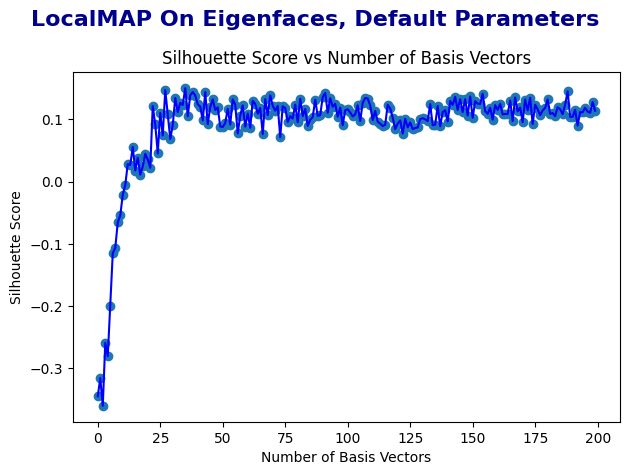

In [ ]:
fig, ax = plt.subplots()
print(len(silhou_score))
ax.scatter(list(range(len(silhou_score))), silhou_score)
ax.set_title(f"Silhouette Score vs Number of Basis Vectors")
ax.set_xlabel("Number of Basis Vectors")
ax.set_ylabel("Silhouette Score")

# Adjust layout and show
fig.suptitle('LocalMAP On Eigenfaces, Default Parameters', fontsize=16, fontweight='bold', color='darkblue')
ax.plot( list(range(len(silhou_score))), silhou_score , color='blue')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np
from scipy.stats import norm
#run evaluations on all of the sets


y=np.load("./eigen_faces_labels.npy",allow_pickle=True)
silhou_score=[]
ITERATIONS : int = 9
for i in range(ITERATIONS):
    file_name : str = f"pca_transformed_eigen_faces_localmap_embedding{i}.npy"

    # load the dataset
    embedding = np.load(file_name)
    # calculate the silhouette score
    silhou_score.append(silhouette_score(embedding, y))

mean_score = np.mean(silhou_score)
std_score = np.std(silhou_score, ddof=1) # ddof=1 for sample standard deviation
n = len(silhou_score)

# Calculate standard error of the mean
sem = std_score / np.sqrt(n)
confidence_level = 0.95
lower_bound, upper_bound = norm.interval(confidence_level, loc=mean_score, scale=sem)
print(lower_bound, upper_bound)
print(mean_score)




-0.04691826913621125 0.005998339393398139
-0.020459965
